In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv('/content/ecommerce_sales_analytics_5000.csv')

In [4]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [6]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


In [7]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

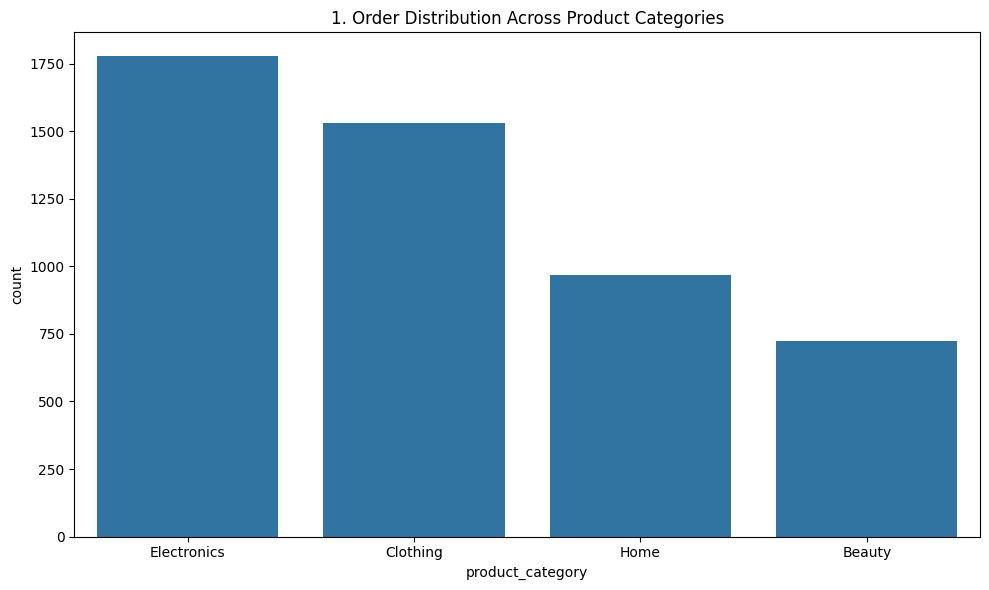

In [8]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='product_category', order=df['product_category'].value_counts().index)
plt.title(f'{plot_no}. Order Distribution Across Product Categories')
show_fig()
plot_no += 1

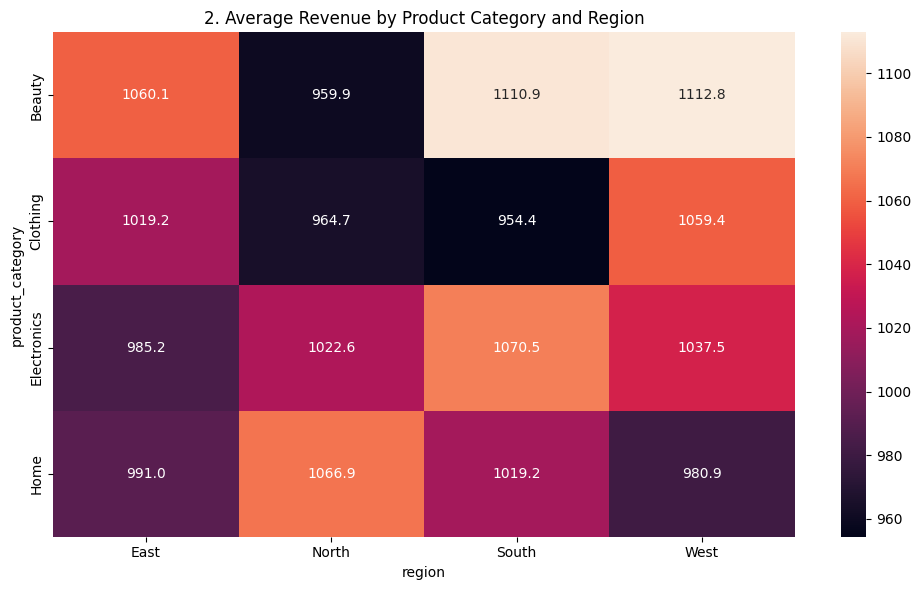

In [9]:
fig = plt.figure(figsize=(10,6))
category_region = df.pivot_table(values='revenue', index='product_category', columns='region', aggfunc='mean')
sns.heatmap(category_region, annot=True, fmt='.1f')
plt.title(f'{plot_no}. Average Revenue by Product Category and Region')
show_fig()
plot_no += 1

In [10]:
X = df.drop('revenue', axis=1)
y = df['revenue']

In [11]:
X['order_date'] = pd.to_datetime(X['order_date'])
X['year'] = X['order_date'].dt.year
X['month'] = X['order_date'].dt.month
X['day'] = X['order_date'].dt.day
X['dayofweek'] = X['order_date'].dt.dayofweek
X = X.drop('order_date', axis=1)

In [12]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [13]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [14]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

In [17]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['order_id', 'customer_id', 'quantity', 'unit_price', 'discount',
       'delivery_days', 'customer_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['product_category', 'region', 'payment_method'], dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

In [18]:
y_pred = model.predict(X_test)

In [19]:
print(f'R² Score : {r2_score(y_test, y_pred):.4f}')
print(f'MAE      : {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE     : {mean_squared_error(y_test, y_pred) ** 0.5:.2f}')

R² Score : 0.9993
MAE      : 17.07
RMSE     : 22.35


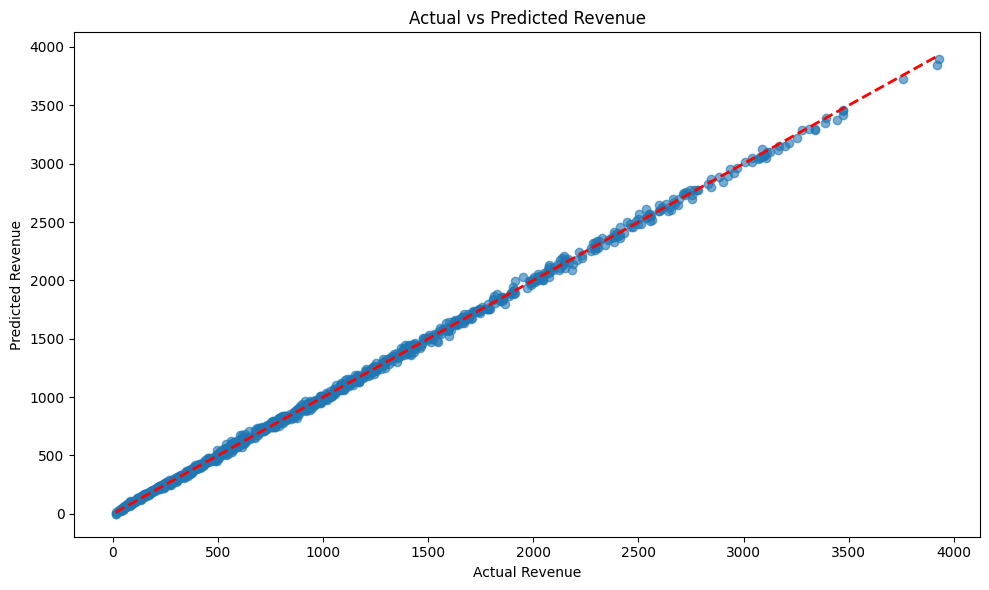

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.tight_layout()
plt.show()